In [2]:
import numpy as np 
import pandas as pd 

In [ ]:
barcodes = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/barcodes.csv")

true_barcodes = [open('/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/barcodes.csv').read().strip().split(',')[2:]]

x_bc_3d = np.load("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_bc.npy")
# flattening 
x_bc_2d = x_bc_3d.reshape(x_bc_3d.shape[0], -1) 
tp = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/timepoints.csv")

timepoints = [str(t) for t in tp]

ln = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/celltypes.csv")
lineages = [open('/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/celltypes.csv').read().strip().split(',')[2:]]
fate_features = [f"{t}_{l}" for t in timepoints for l in lineages]

df_adt = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_adt.csv")
df_adt.index = true_barcodes
# no full X_rna, using 0.9 var
df_rna = pd.read_csv("/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed_filtered_hsc/X_rna_variance_0.90.csv")
df_rna.index = true_barcodes

#df_rna.columns = df_rna.columns.split('_').str[0]
df_fate = pd.DataFrame(np.log2(x_bc_2d + 1), index=true_barcodes)
df_adt.head()
true_barcodes


[['AAAGATCGCACCATT_U\n1',
  'AAAGATGCGTAGGAT_U\n2',
  'AACCAATCGAAGTAT_U\n3',
  'AAGCCATGGTTCATA_U\n4',
  'AATGAAACAATCTAT_U\n5',
  'AATGAATCTATGGAG_U\n6',
  'AATGTTTGCATGGAT_U\n7',
  'ATCCCATGTAGCCTT_U\n8',
  'ATCGTTCCATTCTAT_U\n9',
  'ATTCATAGGACGTAG_U\n10',
  'ATTGGTGCTACGGTT_U\n11',
  'CAACAAACGATGTAT_U\n12',
  'CACCAATCTATCAAG_U\n13',
  'CACCATCCTTGCGTA_U\n14',
  'CACCTTAGCACGTAG_U\n15',
  'CACGGACGTTGCTTA_U\n16',
  'CAGCCAACATGCAAG_U\n17',
  'CAGGTATCGTACCTC_U\n18',
  'CTACCACCATGGTTG_U\n19',
  'CTGCAAGGTTGCTAT_U\n20',
  'CTTGGTACATTGTTT_U\n21',
  'GAGCTTACCAACATT_U\n22',
  'GATGCATGGAGGTAA_U\n23',
  'GATGCTAGTAAGGAA_U\n24',
  'GATGGTAGTACGTAC_U\n25',
  'GTAGCTACGACCTTG_U\n26',
  'GTCCAAGCCACGATT_U\n27',
  'GTCCAATCTATCCTA_U\n28',
  'TAAGAACGGTGGGAG_U\n29',
  'TAAGCATGGATGTTA_U\n30',
  'TACCTATGTTTCTAC_U\n31',
  'TAGCAATCTTTCAAA_U\n32',
  'TAGCTTTGATCGCAC_U\n33',
  'TTGGAATCAATGGTG_U\n34',
  'TTGGCAGCCATGATA_U\n35',
  'TTTGCTTCTATGCTT_U\n36',
  'TTTGGTGCTTTCTTG_U\n37',
  'AAGTGGA

In [4]:
import numpy as np
import pandas as pd
from mofapy2.run.entry_point import entry_point

# =========================
# Load metadata
# =========================

# Barcodes
true_barcodes = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/barcodes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Timepoints
timepoints = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/timepoints.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# Lineages
lineages = (
    open(
        "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/celltypes.csv"
    )
    .read()
    .strip()
    .split(",")[2:]
)

# =========================
# Load fate matrix
# =========================

x_bc_3d = np.load(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_bc.npy"
)

# Flatten
x_bc_2d = x_bc_3d.reshape(x_bc_3d.shape[0], -1)

# Fate feature names
fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# Fate dataframe
df_fate = pd.DataFrame(
    np.log2(x_bc_2d + 1),
    index=true_barcodes,
    columns=fate_features
)

# =========================
# Load RNA / ADT
# =========================

df_rna = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_rna.csv",
    index_col=0
)

df_adt = pd.read_csv(
    "/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed/X_adt.csv",
    index_col=0
)

# Force matching barcodes
df_rna.index = true_barcodes
df_adt.index = true_barcodes

# =========================
# Feature names
# =========================

feat_rna = df_rna.columns.tolist()
feat_adt = df_adt.columns.tolist()
feat_fate = df_fate.columns.tolist()

# =========================
# Convert to matrices
# =========================

mat_rna = df_rna.values.astype(np.float64)
mat_adt = df_adt.values.astype(np.float64)
mat_fate = df_fate.values.astype(np.float64)

# Nested structure:
# views -> groups
data_nested_matrix = [
    [mat_rna],
    [mat_adt],
    [mat_fate]
]
assert list(df_rna.index) == list(df_adt.index)
assert list(df_rna.index) == list(df_fate.index)

# =========================
# Run MOFA
# =========================

ent = entry_point()

ent.set_data_options(
    scale_views=False
)

ent.set_data_matrix(
    data_nested_matrix,
    likelihoods=["gaussian", "gaussian", "gaussian"],
    views_names=["RNA", "ADT", "Fate_Tracking"],
    groups_names=["single_group"],
    samples_names=[true_barcodes],
    features_names=[feat_rna, feat_adt, feat_fate]
)

ent.set_model_options(
    factors=15,
    spikeslab_weights=True
)

ent.set_train_options(
    convergence_mode="medium",
    iter=1000,
    verbose=True
)

ent.build()
ent.run()

ent.save(
    "three_view_cellular_mofa.hdf5",
    save_data=True
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Successfully loaded view='RNA' group='single_group' with N=822 samples and D=17162 features...
Successfully loaded view='ADT' group='single_group' with N=822 samples and D=163 features...
Successfully loaded view='Fate_Tracking' group='single_group' with N=822 samples and D=40 features...



Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Rele

Z shape: (822, 15)
Lineage tensor: (822, 5, 8)
Cluster 0: 117 cells
Cluster 1: 360 cells
Cluster 2: 42 cells
Cluster 3: 121 cells
Cluster 4: 124 cells
Cluster 5: 58 cells


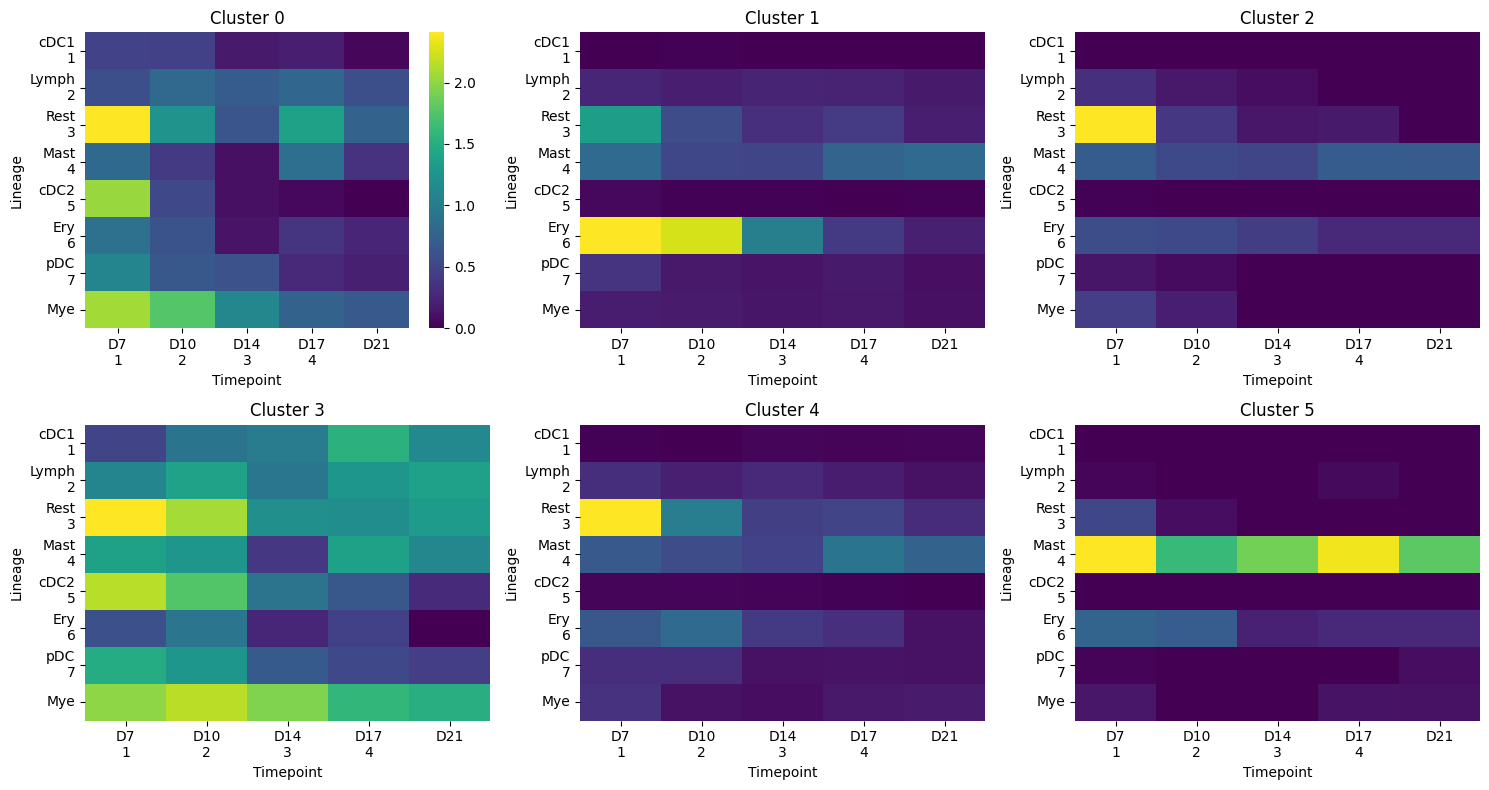

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

# ==========================================
# MOFA latent factors
# ==========================================

Z = ent.model.getExpectations()["Z"]["E"]

print("Z shape:", Z.shape)
# expected: (n_cells, n_factors)

# ==========================================
# Cluster cells in latent space
# ==========================================

n_clusters = 6

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init="auto"
)

clusts = kmeans.fit_predict(Z)

# ==========================================
# Original lineage tensor
# ==========================================

# shape should be:
# (cells, timepoints, lineages)

X_lineage = x_bc_3d

print("Lineage tensor:", X_lineage.shape)

# ==========================================
# Plot cluster-average fate maps
# ==========================================

ncols = 3
nrows = int(np.ceil(n_clusters / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows)
)

axes = axes.flatten()

for cluster_idx in range(n_clusters):

    ax = axes[cluster_idx]

    # select cells in cluster
    mask = clusts == cluster_idx

    print(f"Cluster {cluster_idx}: {mask.sum()} cells")

    # average fate trajectories
    avg = X_lineage[mask].mean(axis=0)

    # avg shape:
    # (timepoints, lineages)

    sns.heatmap(
        avg.T,
        cmap="viridis",
        ax=ax,
        cbar=(cluster_idx == 0),
        xticklabels=timepoints,
        yticklabels=lineages
    )

    ax.set_title(f"Cluster {cluster_idx}")
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Lineage")

# remove empty axes
for i in range(n_clusters, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

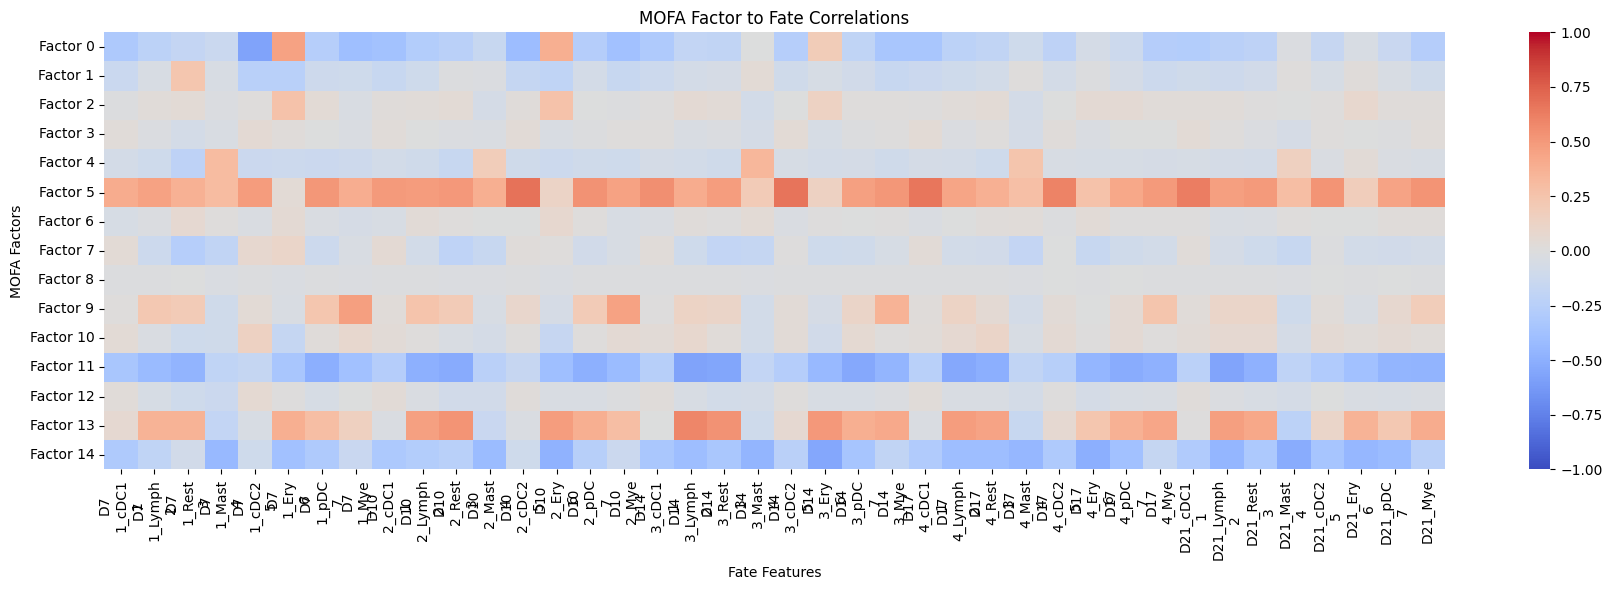

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# Flatten lineage tensor
# ==========================================

# shape:
# (cells, timepoints * lineages)

X_fate_flat = x_bc_3d.reshape(
    x_bc_3d.shape[0],
    -1
)

# feature names
fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# ==========================================
# Compute correlations
# ==========================================

n_factors = Z.shape[1]

corr_mat = np.zeros(
    (n_factors, X_fate_flat.shape[1])
)

for k in range(n_factors):

    for j in range(X_fate_flat.shape[1]):

        corr_mat[k, j] = np.corrcoef(
            Z[:, k],
            X_fate_flat[:, j]
        )[0, 1]

# convert to dataframe
corr_df = pd.DataFrame(
    corr_mat,
    index=[f"Factor {i}" for i in range(n_factors)],
    columns=fate_features
)

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(18, 6))

sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("MOFA Factor to Fate Correlations")
plt.xlabel("Fate Features")
plt.ylabel("MOFA Factors")

plt.tight_layout()
plt.show()


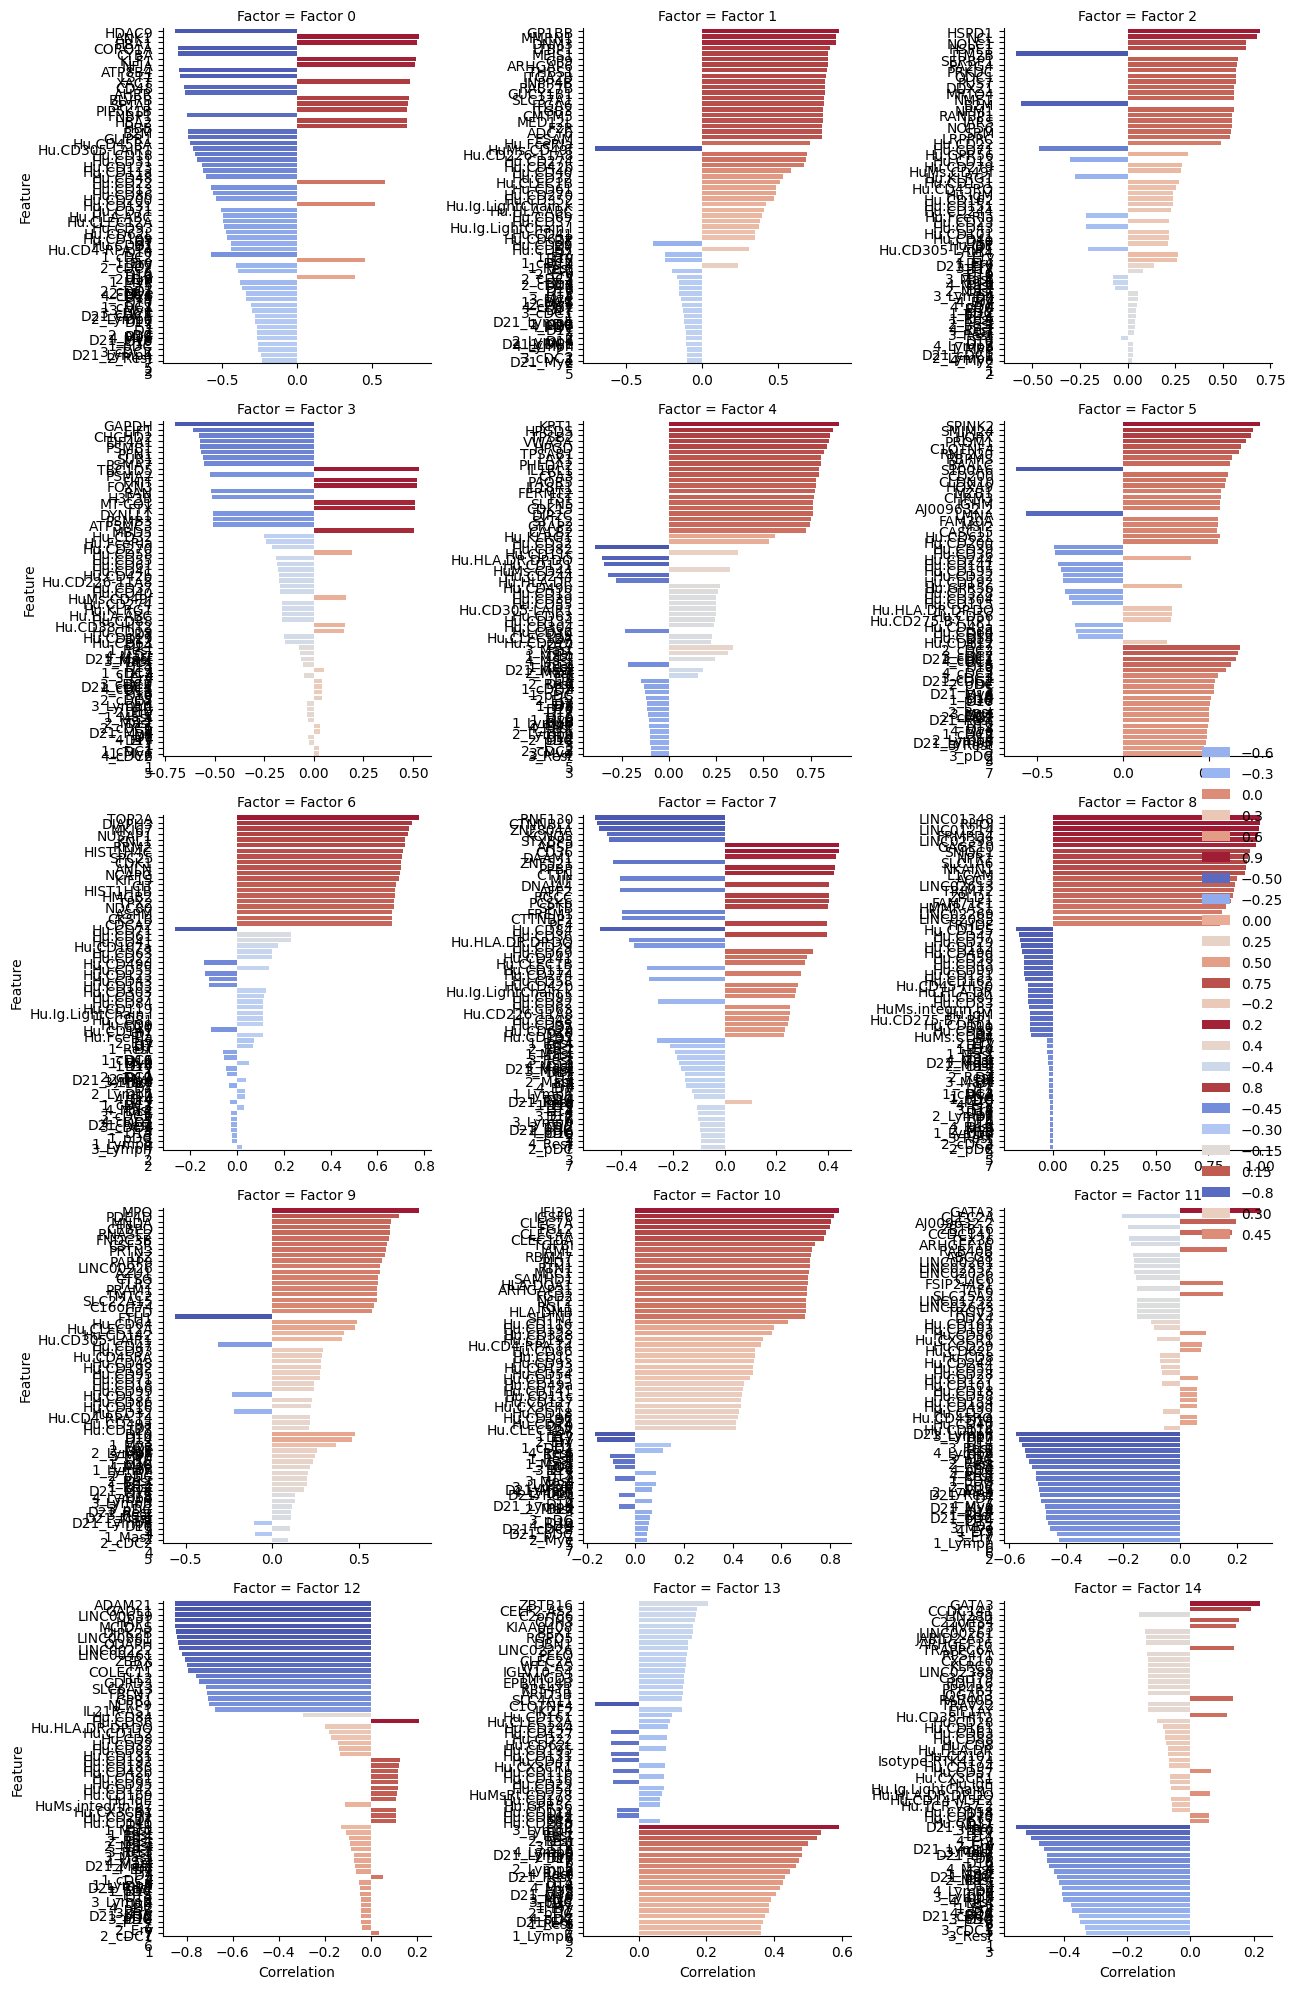

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# Inputs you already have:
# Z              -> (cells × factors)
# df_rna        -> RNA dataframe
# df_adt        -> ADT dataframe
# x_bc_3d       -> fate tensor
# timepoints, lineages
# ==========================================

# --------------------------
# Flatten fate
# --------------------------
X_fate = x_bc_3d.reshape(x_bc_3d.shape[0], -1)

fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]

# --------------------------
# Convert matrices
# --------------------------
mat_rna = df_rna.values
mat_adt = df_adt.values

# --------------------------
# Correlation matrices
# --------------------------
n_factors = Z.shape[1]

corr_rna = np.zeros((n_factors, mat_rna.shape[1]))
corr_adt = np.zeros((n_factors, mat_adt.shape[1]))
corr_fate = np.zeros((n_factors, X_fate.shape[1]))

for k in range(n_factors):

    # RNA
    for j in range(mat_rna.shape[1]):
        corr_rna[k, j] = np.corrcoef(Z[:, k], mat_rna[:, j])[0, 1]

    # ADT
    for j in range(mat_adt.shape[1]):
        corr_adt[k, j] = np.corrcoef(Z[:, k], mat_adt[:, j])[0, 1]

    # Fate
    for j in range(X_fate.shape[1]):
        corr_fate[k, j] = np.corrcoef(Z[:, k], X_fate[:, j])[0, 1]


# --------------------------
# Convert to DataFrames
# --------------------------
corr_rna_df = pd.DataFrame(
    corr_rna,
    index=[f"Factor {i}" for i in range(n_factors)],
    columns=df_rna.columns
)

corr_adt_df = pd.DataFrame(
    corr_adt,
    index=[f"Factor {i}" for i in range(n_factors)],
    columns=df_adt.columns
)

corr_fate_df = pd.DataFrame(
    corr_fate,
    index=[f"Factor {i}" for i in range(n_factors)],
    columns=fate_features
)


# ==========================================
# Extract top features
# ==========================================
def top_features(corr_df, n=20, view="view"):
    rows = []

    for factor in corr_df.index:
        s = corr_df.loc[factor]

        top = s.reindex(
            s.abs().sort_values(ascending=False).index
        ).head(n)

        for feat, val in top.items():
            rows.append({
                "Factor": factor,
                "Feature": feat,
                "Correlation": val,
                "AbsCorr": abs(val),
                "View": view
            })

    return pd.DataFrame(rows)


df_rna_top = top_features(corr_rna_df, 20, "RNA")
df_adt_top = top_features(corr_adt_df, 20, "ADT")
df_fate_top = top_features(corr_fate_df, 20, "Fate")

df_top = pd.concat([df_rna_top, df_adt_top, df_fate_top])


# ==========================================
# Plot (faceted barplots per factor)
# ==========================================
g = sns.FacetGrid(
    df_top,
    col="Factor",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=4
)

g.map_dataframe(
    sns.barplot,
    x="Correlation",
    y="Feature",
    hue="Correlation",
    palette="coolwarm",
    dodge=False
)

g.add_legend()
plt.tight_layout()
plt.show()



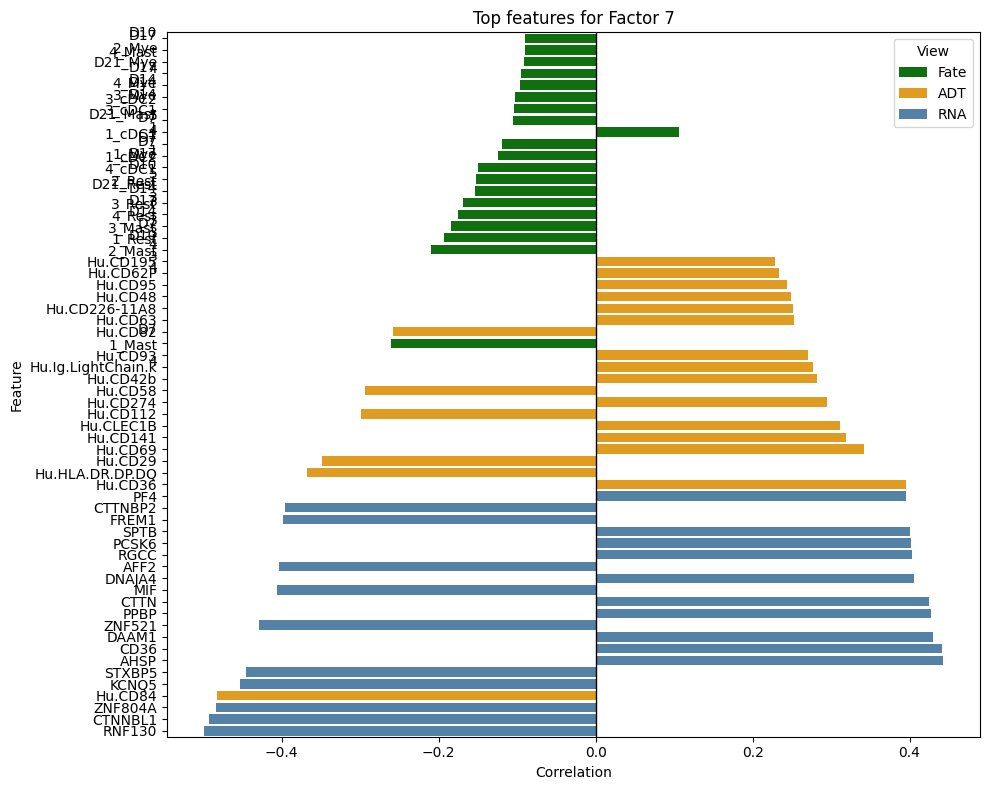

In [28]:
factor_id = 7
factor_name = f"Factor {factor_id}"
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


X_fate = x_bc_3d.reshape(x_bc_3d.shape[0], -1)

fate_features = [
    f"{t}_{l}"
    for t in timepoints
    for l in lineages
]
# Compute correlations for ONE factor only

z = Z[:, factor_id]

def corr_with_view(z, X, feature_names):
    vals = []
    for j in range(X.shape[1]):
        vals.append(np.corrcoef(z, X[:, j])[0, 1])
    return pd.Series(vals, index=feature_names)

rna_corr = corr_with_view(z, df_rna.values, df_rna.columns)
adt_corr = corr_with_view(z, df_adt.values, df_adt.columns)
fate_corr = corr_with_view(z, X_fate, fate_features)

# Get top N features

def top_n(series, n=20):
    return series.reindex(
        series.abs().sort_values(ascending=False).index
    ).head(n)

top_rna = top_n(rna_corr, 20)
top_adt = top_n(adt_corr, 20)
top_fate = top_n(fate_corr, 20)


def to_df(series, view):
    return pd.DataFrame({
        "Feature": series.index,
        "Correlation": series.values,
        "View": view
    })

df_plot = pd.concat([
    to_df(top_rna, "RNA"),
    to_df(top_adt, "ADT"),
    to_df(top_fate, "Fate")
])

# sort for nicer plotting
df_plot["Abs"] = df_plot["Correlation"].abs()
df_plot = df_plot.sort_values("Abs", ascending=True)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_plot,
    x="Correlation",
    y="Feature",
    hue="View",
    palette={"RNA": "steelblue", "ADT": "orange", "Fate": "green"}
)

plt.axvline(0, color="black", linewidth=1)
plt.title(f"Top features for {factor_name}")
plt.tight_layout()
plt.show()

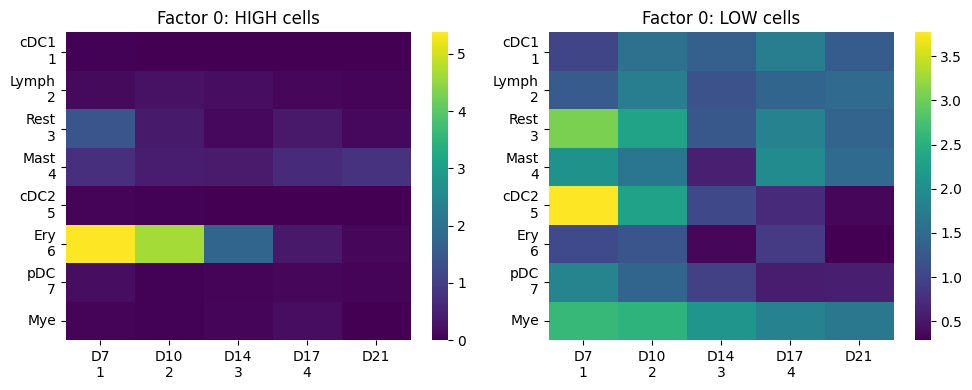

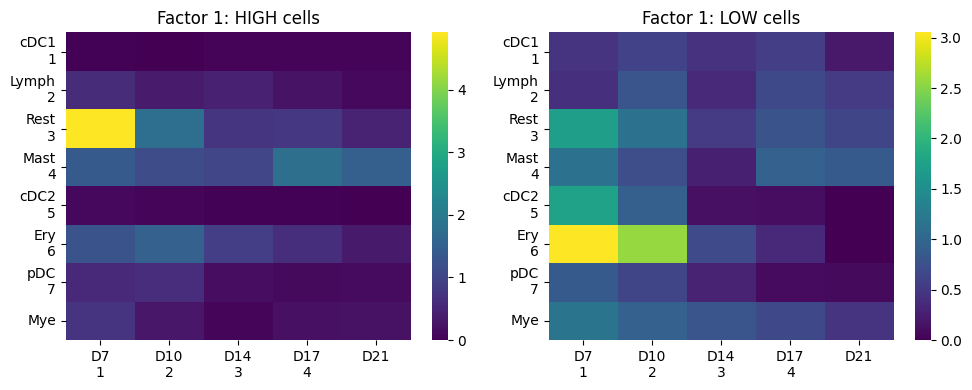

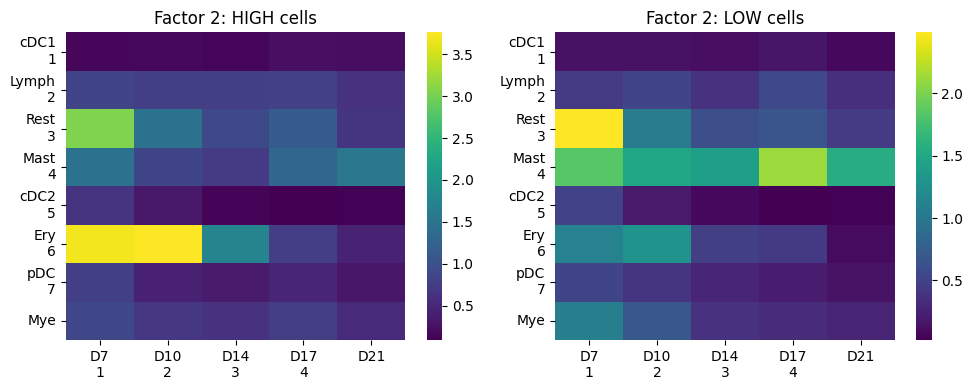

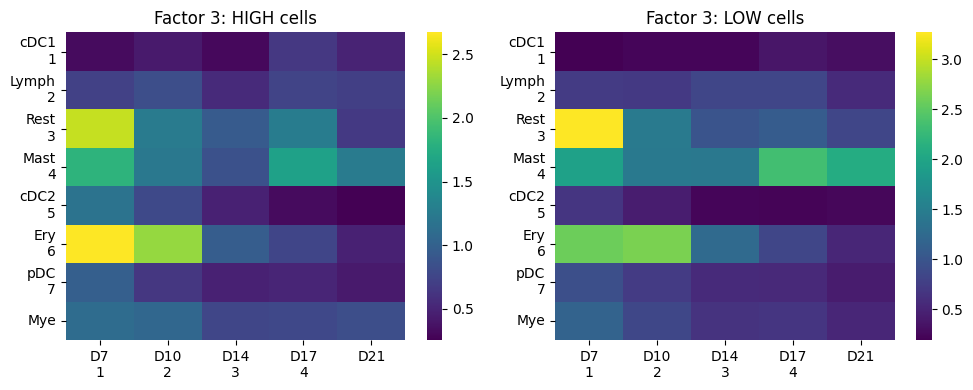

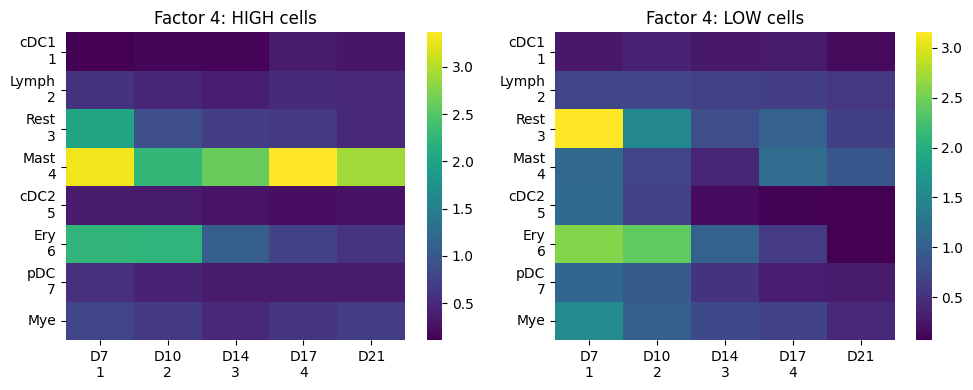

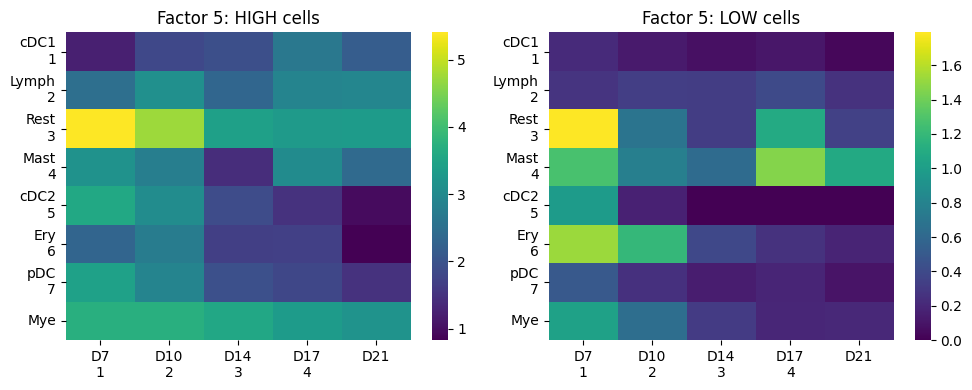

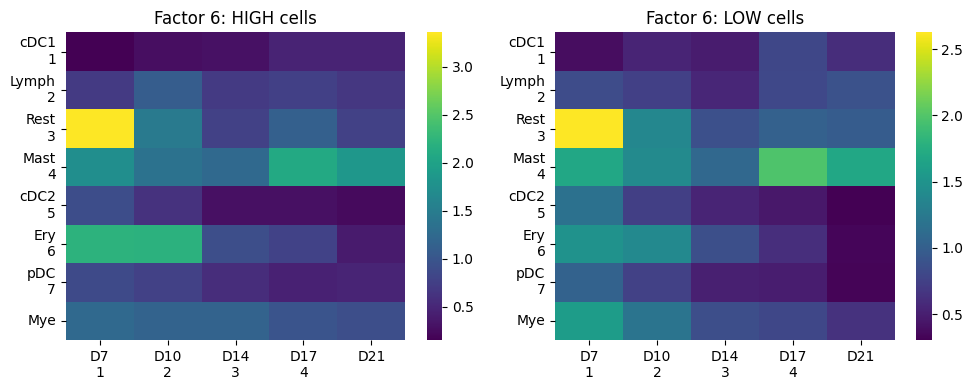

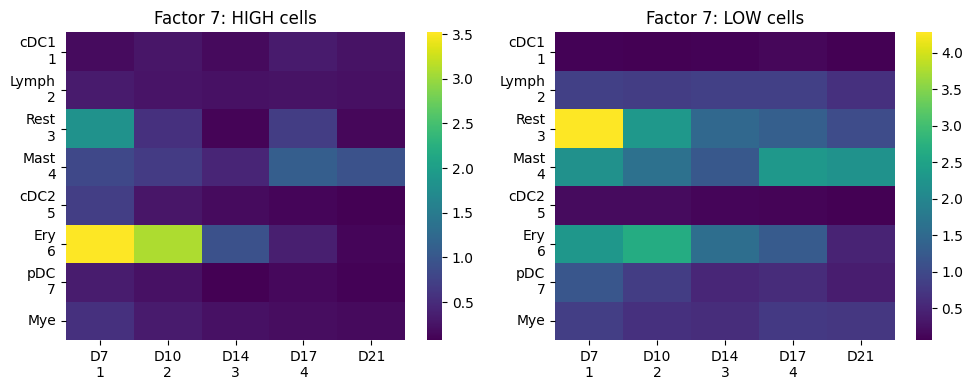

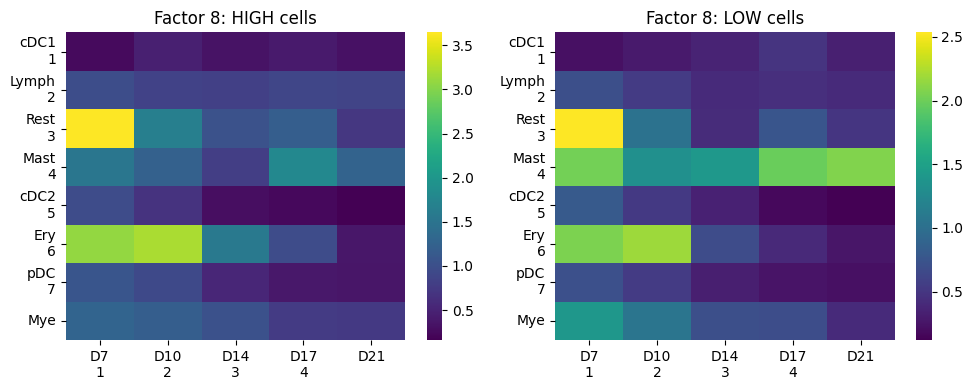

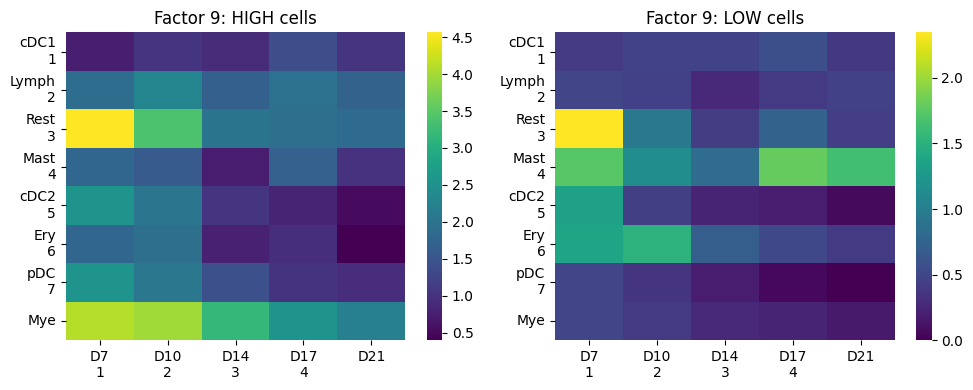

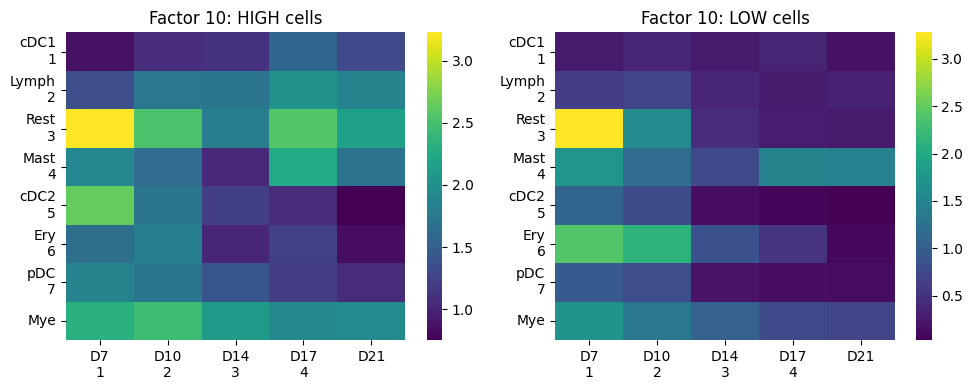

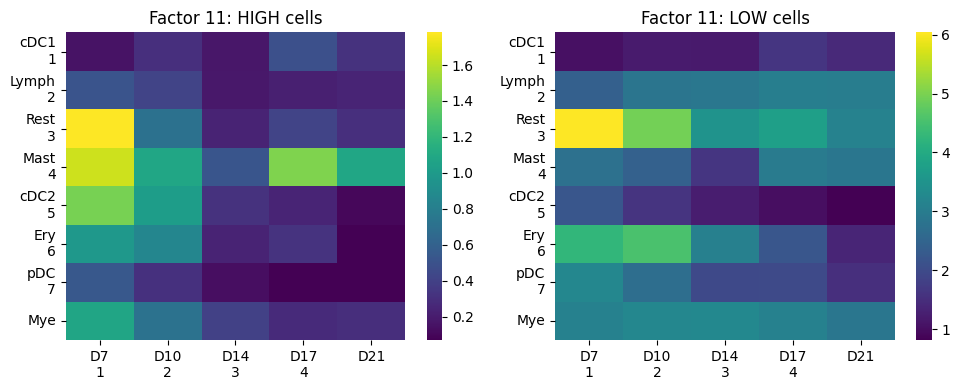

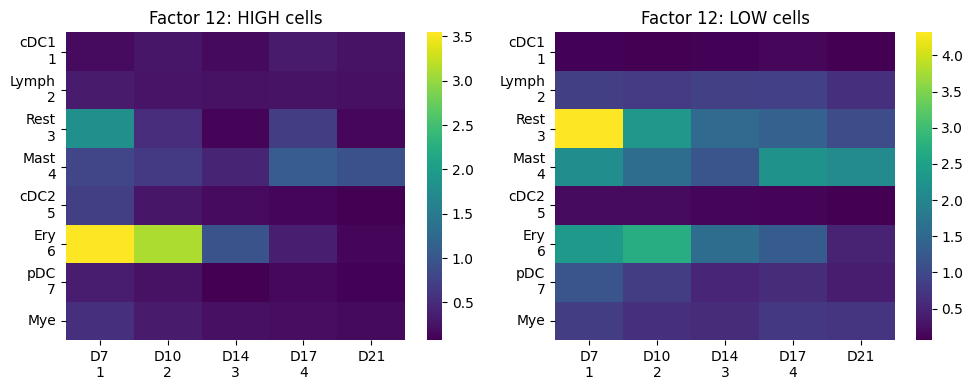

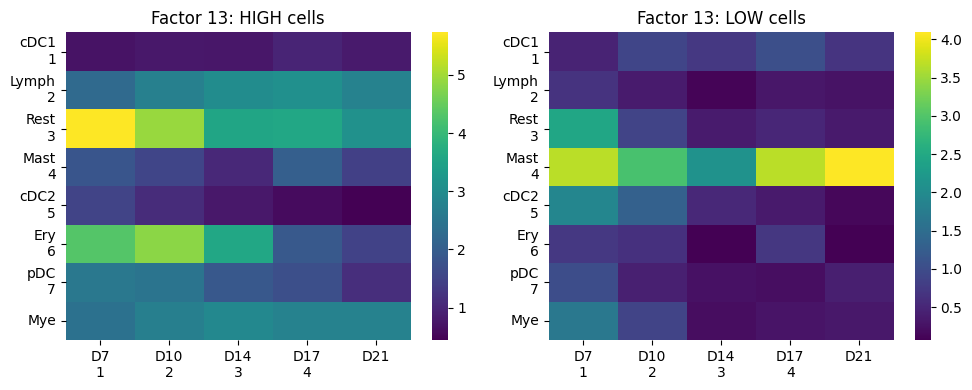

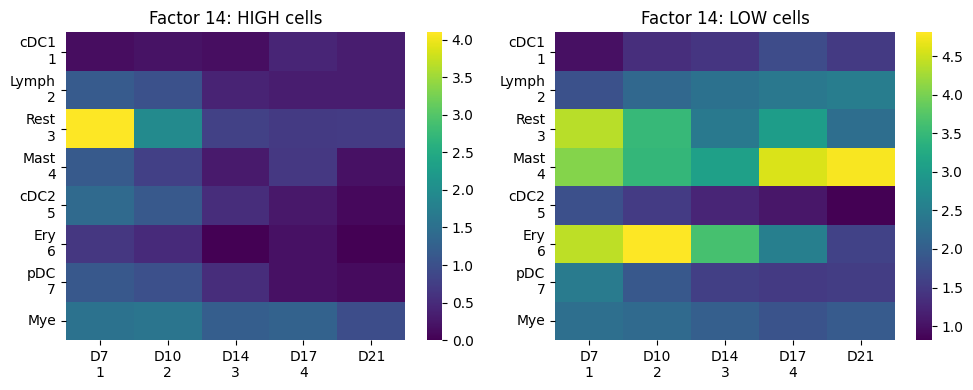

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

quantile = 0.2

n_factors = Z.shape[1]


for factor in range(n_factors):

    scores = Z[:, factor]

    # high / low groups
    hi = scores >= np.quantile(scores, 1 - quantile)
    lo = scores <= np.quantile(scores, quantile)

    # average lineage maps
    avg_hi = x_bc_3d[hi].mean(axis=0)
    avg_lo = x_bc_3d[lo].mean(axis=0)

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(10, 4)
    )

    sns.heatmap(
        avg_hi.T,
        cmap="viridis",
        ax=ax[0],
        xticklabels=timepoints,
        yticklabels=lineages
    )

    ax[0].set_title(
        f"Factor {factor}: HIGH cells"
    )

    sns.heatmap(
        avg_lo.T,
        cmap="viridis",
        ax=ax[1],
        xticklabels=timepoints,
        yticklabels=lineages
    )

    ax[1].set_title(
        f"Factor {factor}: LOW cells"
    )

    plt.tight_layout()
    plt.show()

<Axes: >

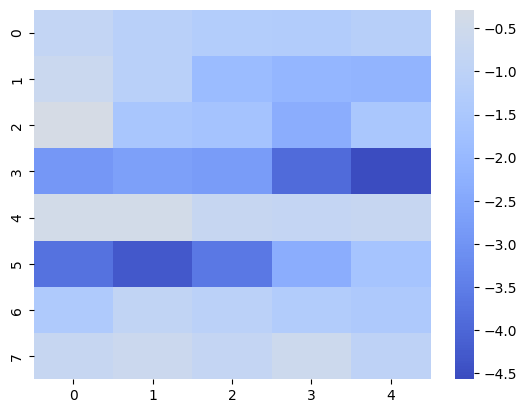

In [9]:
diff = avg_hi - avg_lo
sns.heatmap(
    diff.T,
    cmap="coolwarm",
    center=0
)

steve, reach out tp givanna, why dont u just use mofa, findamentally we need fate infofor this. why does your adapted version work so well? 

Matched ADT features: ['Hu.CD49a', 'Hu.CD31', 'Hu.CD41', 'Hu.CD61', 'Hu.HLA.DR', 'Hu.CD115', 'Hu.CD200']


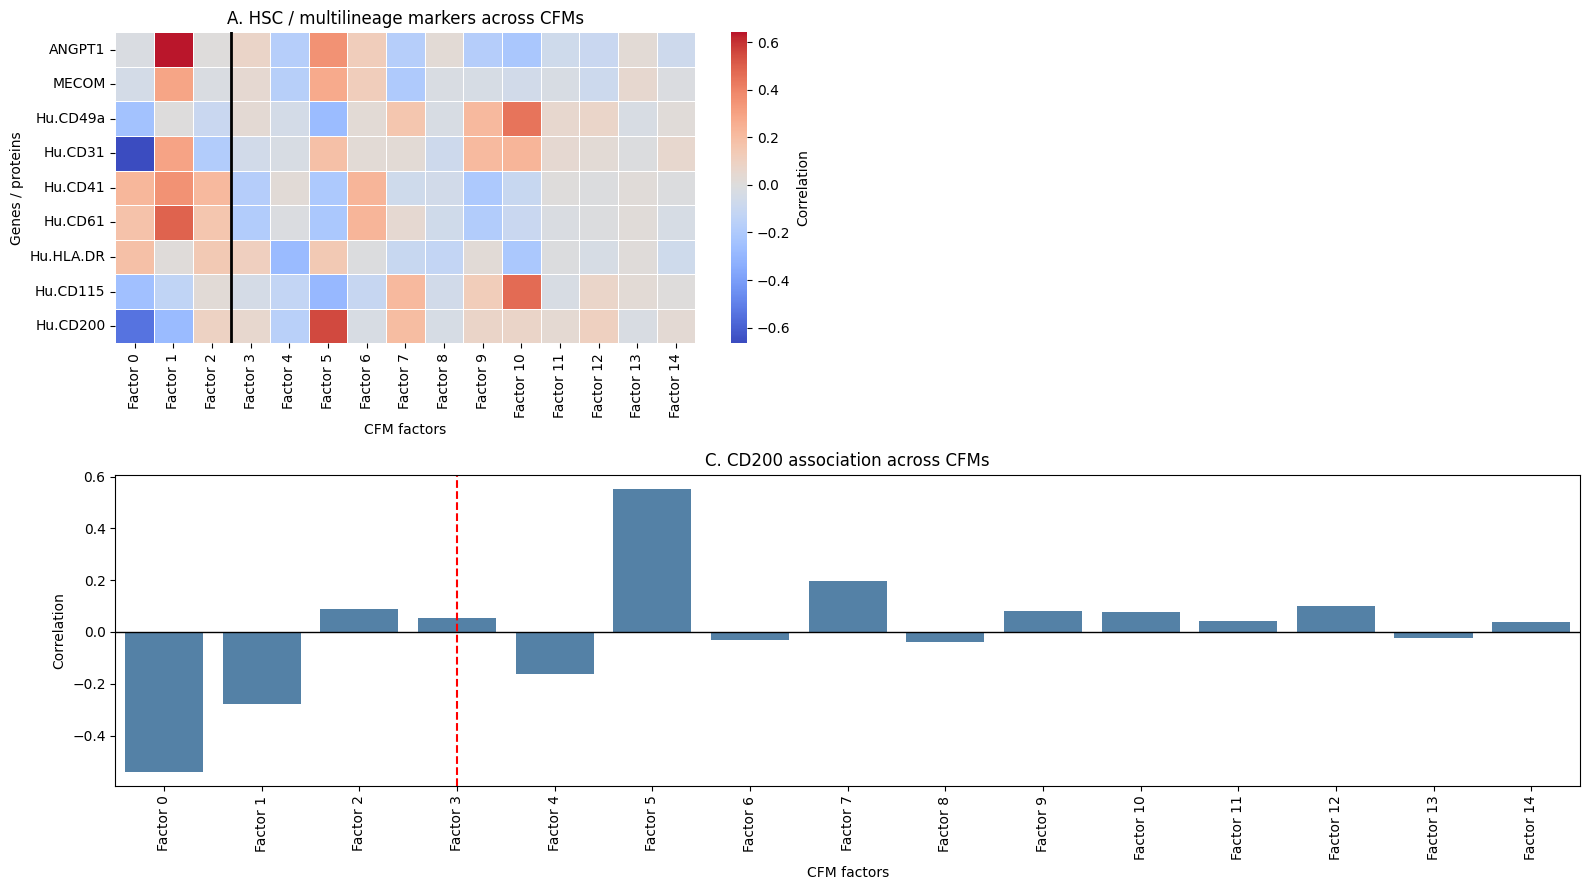

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


corr_all = pd.concat([corr_rna_df, corr_adt_df], axis=1)


# core HSC / multilineage genes (RNA)
gene_targets = ["ANGPT1", "MECOM"]

# ADT markers (panel uses Hu.* naming, finding all possible matches)
adt_patterns = [
    "CD49a",
    "CD31",
    "CD41",
    "CD61",
    "HLA.DR",
    "CD115",
    "CD200"
]

def match_features(patterns, features):
    matched = []
    for p in patterns:
        for f in features:
            if p.lower() in f.lower():
                matched.append(f)
                break
    return matched

adt_targets = match_features(adt_patterns, df_adt.columns)

print("Matched ADT features:", adt_targets)


features_of_interest = gene_targets + adt_targets

features_present = [f for f in features_of_interest if f in corr_all.columns]

gene_heat = corr_all.T.loc[features_present]


fate_df = corr_fate_df.copy()

lineages = list(set([c.split("_")[1] for c in fate_df.columns]))

lineage_matrix = pd.DataFrame(index=fate_df.index)

for l in lineages:
    cols = [c for c in fate_df.columns if c.endswith("_" + l)]
    lineage_matrix[l] = fate_df[cols].mean(axis=1)

# reorder if possible
preferred_order = ["erythroid", "myeloid", "lymphoid", "DC"]
lineage_matrix = lineage_matrix[[l for l in preferred_order if l in lineage_matrix.columns]]

# 5. PLOT (MULTI-PANEL FIGURE)


fig = plt.figure(figsize=(16, 9))


# PANEL A: gene / protein map

ax1 = plt.subplot(2, 2, 1)

sns.heatmap(
    gene_heat,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("A. HSC / multilineage markers across CFMs")
plt.xlabel("CFM factors")
plt.ylabel("Genes / proteins")

# highlight CFM3 (adjust index if needed)
ax1.axvline(3, color="black", linewidth=2)

# # PANEL B: lineage structure
# ax2 = plt.subplot(2, 2, 2)

# sns.heatmap(
#     lineage_matrix.T,
#     cmap="coolwarm",
#     center=0,
#     linewidths=0.5,
#     cbar_kws={"label": "Fate correlation"}
# )

# plt.title("B. Lineage bias of CFMs")
# plt.xlabel("CFM factors")
# plt.ylabel("Lineage")

# ax2.axvline(3, color="black", linewidth=2)

# -----------------------------
# PANEL C: CD31 / endothelial axis (example marker)
# -----------------------------
ax3 = plt.subplot(2, 1, 2)

if "Hu.CD31" in corr_adt_df.columns:

    cd200 = corr_adt_df["Hu.CD200"]

    sns.barplot(
        x=cd31.index,
        y=cd31.values,
        color="steelblue"
    )

    plt.axhline(0, color="black", linewidth=1)
    plt.title("C. CD200 association across CFMs")
    plt.xlabel("CFM factors")
    plt.ylabel("Correlation")

    plt.xticks(rotation=90)

    ax3.axvline(3, color="red", linestyle="--")

plt.tight_layout()
plt.show()

In [22]:
adt_features = df_adt.columns.tolist()
lst = [a for a in adt_features if "200" in a]
lst


['Hu.CD200']